# Toronto Raptors: Statistical Analysis of Championship Decline (2018–2025)
### Python Regression & Correlation Analysis

**Tools:** Python (pandas, matplotlib, seaborn, sklearn) · Google Colab  
**Dataset:** 7 seasons of Raptors team stats (2018–2025)

This project complements the Power BI dashboard with statistical analysis of what drove the Raptors'
championship success in 2019 and subsequent decline. Covers Four Factors evolution, regression modeling,
and correlation analysis against win percentage.

## Four Factors Framework

The "Four Factors" is an analytics framework developed by Dean Oliver (Basketball on Paper, 2004) that identifies the four statistical categories most correlated with winning:

1. **Shooting efficiency (eFG%)**
2. **Turnover rate (TOV%)**  
3. **Offensive rebounding (ORB%)**
4. **Free throw rate (FT Rate)**

These metrics form the basis of the analysis alongside composite offensive and defensive ratings.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Data Loading
Load 7 seasons of Raptors team stats (2018–2025) from Google Sheets.

In [ ]:
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSWM_H2FVZ6cWjqDUDkBQyV-7YWgbkjuufhIAykiDut9oGWI36HEM4WubrBxA0DwrppiDl9zO-_eely/pub?gid=1099310443&single=true&output=csv'

df = pd.read_csv(url)
df

,Season,G,Rrecord,win%,Standing,OFFrtg,DEFrtg,NETrtg,SRS,efg%,tov%,orb%,ft%
0,18-19,82,58-24,0.71,2,113.1,107.1,6.0,5.49,0.543,0.124,0.219,0.247
1,19-20,72,53-19,0.74,2,111.1,105.0,6.1,5.97,0.536,0.131,0.213,0.264
2,20-21,72,27-45,0.38,12,112,112.5,-0.5,-0.54,0.529,0.119,0.208,0.241
3,21-22,82,48-34,0.59,5,112.9,110.5,2.4,2.38,0.510,0.110,0.284,0.234
4,22-23,82,41-41,0.50,9,115.5,114.0,1.5,1.59,0.517,0.103,0.278,0.257
5,23-24,82,25-57,0.30,12,112.3,118.8,-6.4,-6.45,0.535,0.124,0.242,0.241
6,24-25,82,30-52,0.37,11,110.5,114.8,-4.3,-4.40,0.522,0.133,0.273,0.232


## 3. Analysis

### Four Factors Evolution (2018–2025)
How have the four key performance metrics changed season by season?

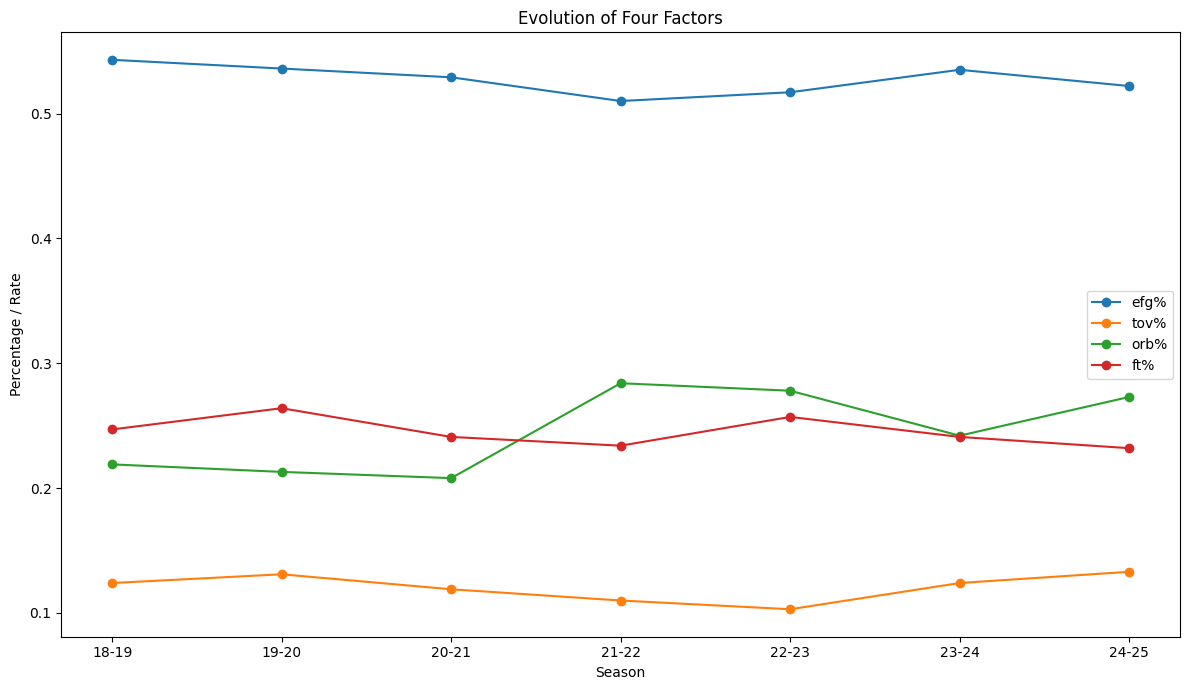

In [ ]:
plot_df = df[['Season', 'efg%', 'tov%', 'orb%', 'ft%']].set_index('Season')

plot_df.plot(marker='o', figsize=(12, 7))
plt.title('Evolution of Four Factors')
plt.xlabel('Season')
plt.ylabel('Percentage / Rate')
plt.tight_layout()
plt.show()

**Finding:** eFG% and defensive metrics declined sharply after the 2019 championship season,
with partial recovery in recent rebuild years. FT rate has remained the most stable factor.

### Regression Analysis — What Predicts Wins?
Two models tested against win percentage:

- **Model 1:** Composite ratings (OFFrtg + DEFrtg)
- **Model 2:** Four Factors (eFG%, TOV%, ORB%, FT%)

In [ ]:
features = ['OFFrtg', 'DEFrtg']
X = df[features]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
for feature, coef in zip(features, reg.coef_):
    print(f'  {feature:10} {coef:7.4f}')

R-squared: 0.933
Intercept: 1.8687

Coefficients:
  OFFrtg      0.0232
  DEFrtg     -0.0355


In [ ]:
features = ['efg%', 'tov%', 'orb%', 'ft%']
X = df[features]
y = df['win%']

reg = LinearRegression()
reg.fit(X, y)

print(f'R-squared: {reg.score(X, y):.3f}')
print(f'Intercept: {reg.intercept_:.4f}\n')

print('Coefficients:')
for feature, coef in zip(features, reg.coef_):
    print(f'  {feature:10} {coef:7.4f}')

R-squared: 0.326
Intercept: -1.4417

Coefficients:
  efg%       -0.5251
  tov%        1.1952
  orb%       -0.0562
  ft%         8.5712


## Model Comparison Results

**Model 1: Composite Ratings**
- **R² = 0.933** - Explains 93.3% of win% variation
- **OffRtg (+0.023):** Each 1-point increase in offensive rating increases win% by ~2.3%
- **DefRtg (-0.036):** Each 1-point increase in defensive rating decreases win% by ~3.6%
- **Interpretation:** Defense has slightly larger impact than offense

**Model 2: Four Factors**
- **R² = 0.326** - Only explains 32.6% of variation
- **Coefficients show unexpected signs** (eFG% negative, TOV% positive)
- **Issue:** Multicollinearity between factors causes unstable coefficient estimates

**Conclusion:**
The composite ratings model (Model 1) is stronger and more reliable for this dataset. The four factors, while theoretically sound, don't perform well when analyzed separately with only 7 seasons of data.

### Correlation Analysis — Metrics vs. Win%
Which individual stats correlate most strongly with winning?

DEFrtg   -0.941370
ft%       0.568167
orb%     -0.241929
efg%      0.227649
OFFrtg    0.111184
tov%      0.014032
dtype: float64


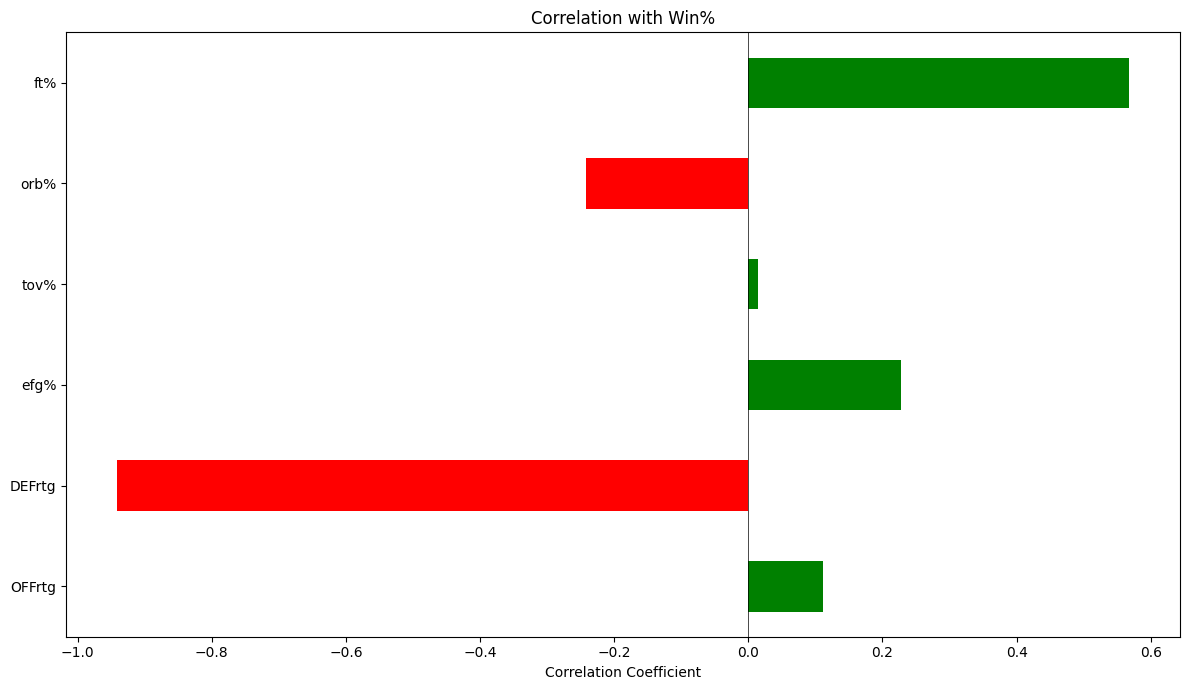

In [ ]:
correlations = df[['OFFrtg', 'DEFrtg', 'efg%', 'tov%', 'orb%', 'ft%']].corrwith(df['win%'])
print(correlations.sort_values(key=abs, ascending=False))

plt.figure(figsize=(12, 7))
correlations.plot(kind='barh', color=['red' if x < 0 else 'green' for x in correlations])
plt.title('Correlation with Win%')
plt.xlabel('Correlation Coefficient')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()



## Correlation Analysis Results

**Correlations with Win% (by strength):**

1. **DefRtg (r = -0.941)**  DOMINANT PREDICTOR
   - Extremely strong negative correlation
   - As defense worsened (higher DefRtg), wins plummeted
   - This is the story: championship team had elite defense, rebuild teams don't

2. **FT Rate (r = 0.568)** - Moderate positive
   - Getting to the free throw line matters
   - Second most important factor

3. **ORB% (r = -0.242)** - Weak negative
   - Counterintuitive: higher rebounding → fewer wins
   - Likely small sample artifact

4. **eFG% (r = 0.228)** - Weak positive
   - Shooting efficiency matters less than expected

5. **OFFrtg (r = 0.111)** - Very weak
   - Offense barely correlates with winning

6. **TOV% (r = 0.014)** - Essentially zero
   - Turnovers don't predict winning in this sample

---
## 4. Summary

**Key Findings:**
- Defensive rating (DefRtg) is by far the strongest predictor of Raptors win% (r = -0.941)
- Composite ratings (OFFrtg + DEFrtg) explain 93% of win variance — a reliable model
- The Four Factors model underperforms due to multicollinearity across a small sample
- The championship era was defined by elite defense; current rebuild teams have not matched it

**Takeaway:**  
For the Raptors to return to contention, defensive improvement is the clearest statistical lever.
Offensive efficiency, while important, has shown weak correlation with winning during this period.

**The Championship-to-Rebuild Story:**
- 2018-19: DefRtg = 107.1 (elite) → 58 wins
- 2023-24: DefRtg = 118.8 (terrible) → 25 wins
- **11.7 point increase in DefRtg = 33 fewer wins**

## Limitations

**Sample Size:**
This analysis uses 7 seasons (2018-2025), which limits statistical power. With only 7 observations:
- Regression coefficients have wide confidence intervals
- Correlation estimates may be unstable
- Multicollinearity impacts Model 2 (Four Factors)

**Why This Timeframe:**
We prioritize narrative coherence over sample size. The 7-season window captures a complete arc: championship → decline → rebuild under consistent modern NBA rules. Extending to 20+ years would include different basketball eras and dilute the specific story being analyzed.

